In [1]:
import os
import cv2
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torchvision.models as tv_models
from torch.optim import Adam
from imutils import paths
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import StratifiedKFold
from sklearn.utils.class_weight import compute_class_weight
from sklearn.model_selection import train_test_split
from utils import FiSHNN, make_weighted_loss, make_loader, train_one_epoch, evaluate, make_single_loader, train_single_epoch, evaluate_single

import warnings
warnings.filterwarnings('ignore')

In [2]:
args = {'dataset': 'otolith_dataset'}

N_SPLITS = 10  # Number of folds for cross-validation
EPOCHS = 200
INIT_LR = 1e-4
BS = 32
IMAGE_DIMS = (256, 256)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"[INFO] using device: {device}")
if device.type == 'cuda':
    print(f"[INFO] GPU Name: {torch.cuda.get_device_name(0)}")

# load images
print('[INFO] loading images...')
imagePaths = sorted(list(paths.list_images(args['dataset'])))
random.seed(42)
random.shuffle(imagePaths)

data = []
species_labels = []
habitat_labels = []
for imagePath in imagePaths:
    image = cv2.imread(imagePath)
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    image = cv2.resize(image, IMAGE_DIMS[::-1])
    data.append(image.astype('float32') / 255.0)
    
    # Path format: .../SPECIES_HABITAT/filename.jpg
    folder_name = imagePath.split(os.path.sep)[-2]
    spe, loc = folder_name.split('_')
    if loc == 'Scheldt': loc = 'SE' # Rename Scheldt to SE
    species_labels.append(spe)
    habitat_labels.append(loc)

data = np.stack(data)
print('[INFO] data matrix: {} images ({:.2f}MB)'.format(len(imagePaths), data.nbytes / (1024 * 1000.0)))

[INFO] using device: cuda
[INFO] GPU Name: NVIDIA GeForce RTX 4090
[INFO] loading images...
[INFO] data matrix: 1389 images (1066.75MB)


In [3]:
# Encode labels
species_le = LabelEncoder()
habitat_le = LabelEncoder()
species_y = species_le.fit_transform(species_labels)
habitat_y = habitat_le.fit_transform(habitat_labels)
num_species = len(species_le.classes_)
num_habitats = len(habitat_le.classes_)
combined_label = [f"{s}-{h}" for s, h in zip(species_y, habitat_y)]

# Compute class weights for balanced loss
species_class_weights = compute_class_weight('balanced', classes=np.unique(species_y), y=species_y)
habitat_class_weights = compute_class_weight('balanced', classes=np.unique(habitat_y), y=habitat_y)
species_weight_dict = dict(enumerate(species_class_weights))
habitat_weight_dict = dict(enumerate(habitat_class_weights))

print('Species classes:', species_le.classes_)
print('Habitat classes:', habitat_le.classes_)

Species classes: ['AF' 'AM' 'AT' 'CH' 'HL' 'SS']
Habitat classes: ['BCS' 'DCS' 'SE']


In [4]:
# Create 8:2 train-test split with stratification based on combined labels
train_full_idx, test_idx = train_test_split(
    np.arange(len(data)),
    test_size=0.2,
    random_state=42,
    stratify=combined_label
)

print(f"[INFO] Training set size: {len(train_full_idx)} ({len(train_full_idx)/len(data)*100:.1f}%)")
print(f"[INFO] Test set size: {len(test_idx)} ({len(test_idx)/len(data)*100:.1f}%)")


# Prepare test set data for later use
test_data = data[test_idx]
test_species_y = species_y[test_idx]
test_habitat_y = habitat_y[test_idx]

print(f"\n[INFO] Test set species distribution:")
test_species_counts = pd.Series(test_species_y)
for i, cls in enumerate(species_le.classes_):
    count = (test_species_y == i).sum()
    print(f"  {cls}: {count}")

print(f"\n[INFO] Test set habitat distribution:")
for i, cls in enumerate(habitat_le.classes_):
    count = (test_habitat_y == i).sum()
    print(f"  {cls}: {count}")

# Save train and test indices and labels for use in Test.ipynb
train_data = data[train_full_idx]
train_species_y = species_y[train_full_idx]
train_habitat_y = habitat_y[train_full_idx]

os.makedirs('models', exist_ok=True)
np.save('models/train_idx.npy', train_full_idx)
np.save('models/test_idx.npy', test_idx)
np.save('models/species_le.npy', species_le.classes_)
np.save('models/habitat_le.npy', habitat_le.classes_)

[INFO] Training set size: 1111 (80.0%)
[INFO] Test set size: 278 (20.0%)

[INFO] Test set species distribution:
  AF: 4
  AM: 26
  AT: 47
  CH: 109
  HL: 9
  SS: 83

[INFO] Test set habitat distribution:
  BCS: 200
  DCS: 70
  SE: 8


## FiSHNN Multi-task Training

In [5]:
# Cross-validation training on training set
import time
skf = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=42)

fold_histories = []
best_state_global = None
best_max_acc_sum_global = -1.0

# Prepare combined labels for training set only
train_full_combined_label = [combined_label[i] for i in train_full_idx]

for fold, (train_cv_idx, val_cv_idx) in enumerate(skf.split(train_full_idx, train_full_combined_label)):
    # Map back to original indices
    train_idx = train_full_idx[train_cv_idx]
    val_idx = train_full_idx[val_cv_idx]
    
    print(f"\n[INFO] FiSHNN Fold {fold + 1}/{N_SPLITS}")
    train_loader = make_loader(data, species_y, habitat_y, train_idx, BS, shuffle=True)
    val_loader = make_loader(data, species_y, habitat_y, val_idx, BS, shuffle=False)

    model = FiSHNN(num_species=num_species, num_habitats=num_habitats).to(device)
    opt = Adam(model.parameters(), lr=INIT_LR)
    crit_species = make_weighted_loss(species_weight_dict, device)
    crit_habitat = make_weighted_loss(habitat_weight_dict, device)

    history = {
        'train_loss': [], 'val_loss': [],
        'train_loss_species': [], 'val_loss_species': [],
        'train_loss_habitat': [], 'val_loss_habitat': [],
        'train_acc_species': [], 'val_acc_species': [],
        'train_acc_habitat': [], 'val_acc_habitat': [],
        'fold_time': 0.0}

    best_acc_sum = -1.0
    best_state = None

    fold_start = time.time()
    for epoch in range(EPOCHS):
        tr_loss, tr_loss_s, tr_loss_h, tr_acc_s, tr_acc_h = train_one_epoch(model, train_loader, opt, crit_species, crit_habitat, device)
        val_loss, val_loss_s, val_loss_h, val_acc_s, val_acc_h, _, _, _, _ = evaluate(model, val_loader, crit_species, crit_habitat, device)

        history['train_loss'].append(tr_loss)
        history['val_loss'].append(val_loss)
        history['train_loss_species'].append(tr_loss_s)
        history['val_loss_species'].append(val_loss_s)
        history['train_loss_habitat'].append(tr_loss_h)
        history['val_loss_habitat'].append(val_loss_h)
        history['train_acc_species'].append(tr_acc_s)
        history['val_acc_species'].append(val_acc_s)
        history['train_acc_habitat'].append(tr_acc_h)
        history['val_acc_habitat'].append(val_acc_h)

        if (epoch + 1) % 10 == 0 or epoch == 0:
            print(
                f"Epoch {epoch + 1:03d}/{EPOCHS} | "
                f"train_loss {tr_loss:.4f} (spe {tr_loss_s:.4f}, hab {tr_loss_h:.4f}) "
                f"val_loss {val_loss:.4f} (spe {val_loss_s:.4f}, hab {val_loss_h:.4f}) | "
                f"val_acc species {val_acc_s:.3f} habitat {val_acc_h:.3f}"
            )

        # Selection criteria: Maximum sum of accuracies (Balanced optimal)
        current_acc_sum = val_acc_s + val_acc_h
        if current_acc_sum > best_acc_sum:
            best_acc_sum = current_acc_sum
            best_state = model.state_dict().copy()
            
            # Update global best model
            if current_acc_sum > best_max_acc_sum_global:
                best_max_acc_sum_global = current_acc_sum
                best_state_global = best_state.copy()

    history['fold_time'] = time.time() - fold_start
    fold_histories.append(history)

# Save best FiSHNN model
if best_state_global is not None:
    torch.save(best_state_global, 'models/FiSHNN_best.pt')


[INFO] FiSHNN Fold 1/10
Epoch 001/200 | train_loss 2.2153 (spe 1.3892, hab 0.8260) val_loss 1.5872 (spe 1.0478, hab 0.5393) | val_acc species 0.812 habitat 0.884
Epoch 010/200 | train_loss 0.0426 (spe 0.0283, hab 0.0143) val_loss 0.4538 (spe 0.2931, hab 0.1608) | val_acc species 0.973 habitat 0.973
Epoch 020/200 | train_loss 0.0175 (spe 0.0129, hab 0.0046) val_loss 0.4716 (spe 0.2722, hab 0.1995) | val_acc species 0.991 habitat 0.973
Epoch 030/200 | train_loss 0.0196 (spe 0.0115, hab 0.0081) val_loss 0.6383 (spe 0.3842, hab 0.2541) | val_acc species 0.982 habitat 0.964
Epoch 040/200 | train_loss 0.0247 (spe 0.0236, hab 0.0011) val_loss 0.5162 (spe 0.2786, hab 0.2375) | val_acc species 0.991 habitat 0.964
Epoch 050/200 | train_loss 0.0046 (spe 0.0036, hab 0.0010) val_loss 0.6064 (spe 0.3657, hab 0.2408) | val_acc species 0.991 habitat 0.964
Epoch 060/200 | train_loss 0.0025 (spe 0.0022, hab 0.0003) val_loss 0.7420 (spe 0.4957, hab 0.2463) | val_acc species 0.982 habitat 0.973
Epoch 070

## Single-task Baselines (EfficientNet Branches)

In [6]:
# Training single-task models for comparison
# EfficientNet-B0 (Transfer Learning)

single_task_histories = {}
best_states = {}

configs = [
    ("EfficientNet_Species", species_y, num_species, species_weight_dict),
    ("EfficientNet_Habitat", habitat_y, num_habitats, habitat_weight_dict)]

for name, full_labels, num_classes, weight_dict in configs:
    print(f"\n[INFO] Training single-task model: {name}")
    train_task_labels = full_labels[train_full_idx]
    skf = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=42)
    
    fold_accs = []
    best_overall_acc = 0.0
    histories = []
    
    for fold, (train_cv_idx, val_cv_idx) in enumerate(skf.split(train_full_idx, train_task_labels)):
        train_idx = train_full_idx[train_cv_idx]
        val_idx = train_full_idx[val_cv_idx]
        
        print(f"  Fold {fold + 1}/{N_SPLITS}")
        train_loader = make_single_loader(data, train_idx, full_labels, BS, shuffle=True)
        val_loader = make_single_loader(data, val_idx, full_labels, BS, shuffle=False)

        # Initialize model: Only EfficientNet-B0 (Single Task)
        model = tv_models.efficientnet_b0(weights="DEFAULT")
        model.classifier = nn.Sequential(nn.Dropout(p=0.2, inplace=True), nn.Linear(1280, num_classes))
            
        model = model.to(device)
        opt = Adam(model.parameters(), lr=INIT_LR)
        criterion = make_weighted_loss(weight_dict, device)

        history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': [], 'fold_time': 0.0}
        best_fold_acc = 0.0
        fold_start = time.time()
        for epoch in range(EPOCHS):
            tr_loss, tr_acc = train_single_epoch(model, train_loader, opt, criterion, device)
            val_loss, val_acc = evaluate_single(model, val_loader, criterion, device)
            
            history['train_loss'].append(tr_loss)
            history['val_loss'].append(val_loss)
            history['train_acc'].append(tr_acc)
            history['val_acc'].append(val_acc)
            
            if val_acc > best_fold_acc:
                best_fold_acc = val_acc
                if val_acc > best_overall_acc:
                    best_overall_acc = val_acc
                    best_states[name] = model.state_dict().copy()

        history['fold_time'] = time.time() - fold_start
        histories.append(history)
        fold_accs.append(best_fold_acc)
        print(f"Best Val Acc: {best_fold_acc:.4f}")

    print(f"[RESULT] {name} Mean Acc: {np.mean(fold_accs):.4f}")
    single_task_histories[name] = histories
    
    # Save best model
    torch.save(best_states[name], f"models/{name}_best.pt")


[INFO] Training single-task model: EfficientNet_Species
  Fold 1/10
Best Val Acc: 1.0000
  Fold 2/10
Best Val Acc: 0.9820
  Fold 3/10
Best Val Acc: 0.9820
  Fold 4/10
Best Val Acc: 1.0000
  Fold 5/10
Best Val Acc: 0.9820
  Fold 6/10
Best Val Acc: 0.9910
  Fold 7/10
Best Val Acc: 0.9910
  Fold 8/10
Best Val Acc: 0.9910
  Fold 9/10
Best Val Acc: 0.9910
  Fold 10/10
Best Val Acc: 1.0000
[RESULT] EfficientNet_Species Mean Acc: 0.9910

[INFO] Training single-task model: EfficientNet_Habitat
  Fold 1/10
Best Val Acc: 1.0000
  Fold 2/10
Best Val Acc: 1.0000
  Fold 3/10
Best Val Acc: 0.9910
  Fold 4/10
Best Val Acc: 0.9910
  Fold 5/10
Best Val Acc: 0.9820
  Fold 6/10
Best Val Acc: 1.0000
  Fold 7/10
Best Val Acc: 1.0000
  Fold 8/10
Best Val Acc: 1.0000
  Fold 9/10
Best Val Acc: 0.9910
  Fold 10/10
Best Val Acc: 0.9910
[RESULT] EfficientNet_Habitat Mean Acc: 0.9946


## Training Curves

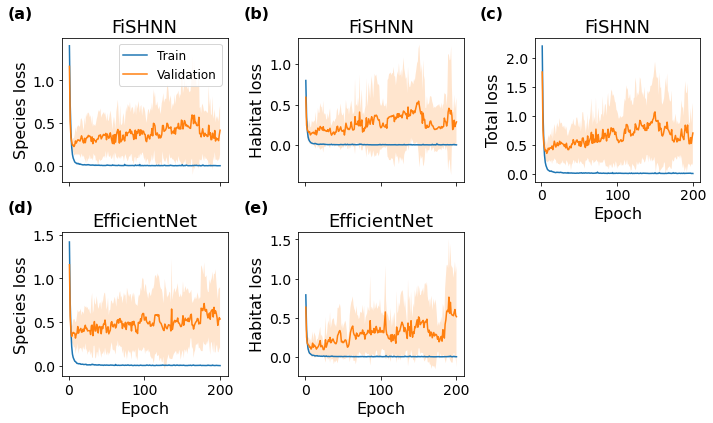

In [7]:
# Plot averaged losses (mean ± std) for MTL and STL

# MTL Data
mtl_train_loss = np.stack([h['train_loss'] for h in fold_histories])
mtl_val_loss = np.stack([h['val_loss'] for h in fold_histories])
mtl_train_loss_s = np.stack([h['train_loss_species'] for h in fold_histories])
mtl_val_loss_s = np.stack([h['val_loss_species'] for h in fold_histories])
mtl_train_loss_h = np.stack([h['train_loss_habitat'] for h in fold_histories])
mtl_val_loss_h = np.stack([h['val_loss_habitat'] for h in fold_histories])

# STL Data
stl_s_train = np.stack([h['train_loss'] for h in single_task_histories['EfficientNet_Species']])
stl_s_val = np.stack([h['val_loss'] for h in single_task_histories['EfficientNet_Species']])
stl_h_train = np.stack([h['train_loss'] for h in single_task_histories['EfficientNet_Habitat']])
stl_h_val = np.stack([h['val_loss'] for h in single_task_histories['EfficientNet_Habitat']])

fig, ax = plt.subplots(2, 3, figsize=(10, 6))
epochs = np.arange(1, mtl_train_loss.shape[1] + 1)

# Row 1: MTL Losses (Species, Habitat, Total)
plot_configs_mtl = [
    (mtl_train_loss_s, mtl_val_loss_s, 'Species loss', 0, 0, '(a)'),
    (mtl_train_loss_h, mtl_val_loss_h, 'Habitat loss', 0, 1, '(b)'),
    (mtl_train_loss, mtl_val_loss, 'Total loss', 0, 2, '(c)')]
plot_configs_stl = [
    (stl_s_train, stl_s_val, 'Species loss', 1, 0, '(d)'),
    (stl_h_train, stl_h_val, 'Habitat loss', 1, 1, '(e)')]

for arr_tr, arr_val, ylabel, r, c, label_idx in plot_configs_mtl + plot_configs_stl:
    mean_tr, std_tr = arr_tr.mean(0), arr_tr.std(0)
    mean_val, std_val = arr_val.mean(0), arr_val.std(0)
    ax[r, c].plot(epochs, mean_tr, label='Train')
    ax[r, c].fill_between(epochs, mean_tr - std_tr, mean_tr + std_tr, alpha=0.2)
    ax[r, c].plot(epochs, mean_val, label='Validation')
    ax[r, c].fill_between(epochs, mean_val - std_val, mean_val + std_val, alpha=0.2)
    ax[r, c].text(-0.33, 1.22, label_idx, transform=ax[r, c].transAxes, ha='left', va='top', fontsize=16, fontweight='bold')
    
    # Set ylabel as original, but title only as MTL/STL
    ax[r, c].set_ylabel(ylabel, fontsize=16)
    ax[r, c].set_title('FiSHNN' if r == 0 else 'EfficientNet', fontsize=18)
    
    # Shared x-label logic
    if r == 1 or (r == 0 and c == 2):
        ax[r, c].set_xlabel('Epoch', fontsize=16)
    else:
        ax[r, c].tick_params(labelbottom=False)

    ax[r, c].tick_params(axis='both', labelsize=14)

ax[0, 0].legend(fontsize=12, loc='upper right')
ax[1, 2].axis('off')

plt.tight_layout()
plt.savefig('./Figs/Figure_S1_loss.pdf')
plt.savefig('./Figs/Figure_S1_loss.png', dpi=600, bbox_inches='tight')

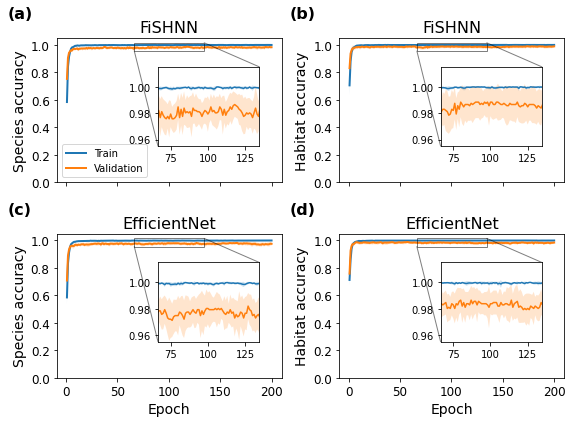

In [8]:
# Plot averaged accuracies for species and habitat (mean ± std) in 2x2 (MTL vs STL)

# MTL Data
mtl_train_acc_s = np.stack([h['train_acc_species'] for h in fold_histories])
mtl_val_acc_s = np.stack([h['val_acc_species'] for h in fold_histories])
mtl_train_acc_h = np.stack([h['train_acc_habitat'] for h in fold_histories])
mtl_val_acc_h = np.stack([h['val_acc_habitat'] for h in fold_histories])

# STL Data
stl_s_train_acc = np.stack([h['train_acc'] for h in single_task_histories['EfficientNet_Species']])
stl_s_val_acc = np.stack([h['val_acc'] for h in single_task_histories['EfficientNet_Species']])
stl_h_train_acc = np.stack([h['train_acc'] for h in single_task_histories['EfficientNet_Habitat']])
stl_h_val_acc = np.stack([h['val_acc'] for h in single_task_histories['EfficientNet_Habitat']])

# Consistent with Figure S2: Titles as model names, y-labels as task names
fig, ax = plt.subplots(2, 2, figsize=(8, 6))
epochs = np.arange(1, mtl_train_acc_s.shape[1] + 1)

plot_configs = [
    (mtl_train_acc_s, mtl_val_acc_s, 'Species accuracy', 0, 0, '(a)'),
    (mtl_train_acc_h, mtl_val_acc_h, 'Habitat accuracy', 0, 1, '(b)'),
    (stl_s_train_acc, stl_s_val_acc, 'Species accuracy', 1, 0, '(c)'),
    (stl_h_train_acc, stl_h_val_acc, 'Habitat accuracy', 1, 1, '(d)')]

for arr_tr, arr_val, ylabel, r, c, label_idx in plot_configs:
    mean_tr, std_tr = arr_tr.mean(0), arr_tr.std(0)
    mean_val, std_val = arr_val.mean(0), arr_val.std(0)
    
    # Primary plot
    ax[r, c].plot(epochs, mean_tr, label='Train', linewidth=2)
    ax[r, c].fill_between(epochs, mean_tr - std_tr, mean_tr + std_tr, alpha=0.2)
    ax[r, c].plot(epochs, mean_val, label='Validation', linewidth=2)
    ax[r, c].fill_between(epochs, mean_val - std_val, mean_val + std_val, alpha=0.2)
    ax[r, c].text(-0.22, 1.22, label_idx, transform=ax[r, c].transAxes, ha='left', va='top', fontsize=16, fontweight='bold')
    
    # Set labels and titles
    ax[r, c].set_ylabel(ylabel, fontsize=14)
    ax[r, c].set_title('FiSHNN' if r == 0 else 'EfficientNet', fontsize=16)
    
    if r == 1:
        ax[r, c].set_xlabel('Epoch', fontsize=14)
    else:
        ax[r, c].tick_params(labelbottom=False)

    ax[r, c].set_ylim([0, 1.05])
    ax[r, c].tick_params(axis='both', labelsize=12)

    # Local Zoom (Inset Axes) - Using native ax.inset_axes to avoid mpl_toolkits bug
    # [x0, y0, width, height] in normalized units of the parent axes
    axins = ax[r, c].inset_axes([0.45, 0.25, 0.45, 0.55])
    axins.plot(epochs, mean_tr, linewidth=1.5)
    axins.fill_between(epochs, mean_tr - std_tr, mean_tr + std_tr, alpha=0.2)
    axins.plot(epochs, mean_val, linewidth=1.5)
    axins.fill_between(epochs, mean_val - std_val, mean_val + std_val, alpha=0.2)
    
    # Focus on the 1/3 to 2/3 range of epochs
    n_epochs = len(epochs)
    x1, x2 = epochs[n_epochs // 3] - 0.5, epochs[2 * n_epochs // 3] + 0.5
    y1, y2 = 0.955, 1.015
    axins.set_xlim(x1, x2)
    axins.set_ylim(y1, y2)
    axins.tick_params(labelsize=10)
    
    # Draw indicators to show where the zoom comes from
    ax[r, c].indicate_inset_zoom(axins, edgecolor="black")

ax[0, 0].legend(fontsize=10, loc='lower left')

plt.tight_layout()
plt.savefig('./Figs/Figure_S2_accuracy.pdf')
plt.savefig('./Figs/Figure_S2_accuracy.png', dpi=600, bbox_inches='tight')

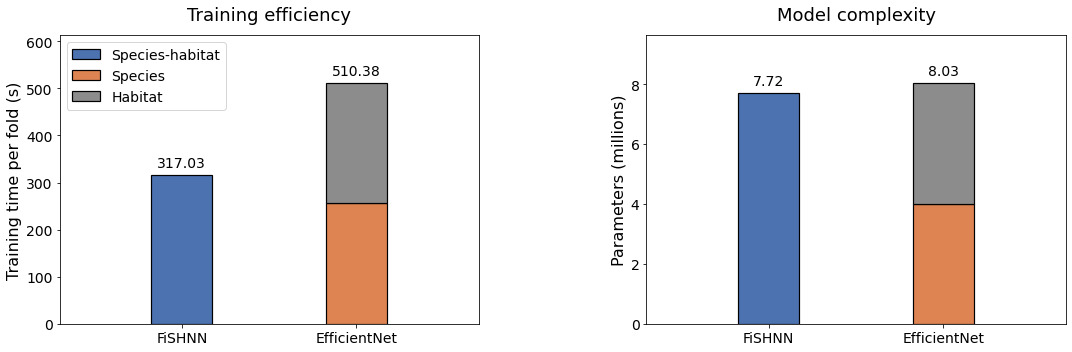

In [9]:
# Plot Model Complexity (Parameters) and Training Efficiency (Time) Comparison (Stacked)

# Calculate Parameter Counts
def count_parameters(model):
    return sum(p.numel() for p in model.parameters())

# FiSHNN (MTL)
model_mtl = FiSHNN(num_species=num_species, num_habitats=num_habitats)
mtl_params = count_parameters(model_mtl)

# EfficientNet (STL Species)
model_stl_s = tv_models.efficientnet_b0()
model_stl_s.classifier = nn.Sequential(nn.Dropout(p=0.2), nn.Linear(1280, num_species))
stl_s_params = count_parameters(model_stl_s)

# EfficientNet (STL Habitat)
model_stl_h = tv_models.efficientnet_b0()
model_stl_h.classifier = nn.Sequential(nn.Dropout(p=0.2), nn.Linear(1280, num_habitats))
stl_h_params = count_parameters(model_stl_h)

# Prepare Training Time data (Average time per fold)
mtl_time_mean = np.mean([h['fold_time'] for h in fold_histories])
stl_s_time_mean = np.mean([h['fold_time'] for h in single_task_histories['EfficientNet_Species']])
stl_h_time_mean = np.mean([h['fold_time'] for h in single_task_histories['EfficientNet_Habitat']])

# Data for plotting
params_data = [mtl_params / 1e6, stl_s_params / 1e6, stl_h_params / 1e6]
time_data = [mtl_time_mean, stl_s_time_mean, stl_h_time_mean]

# Plotting
fig, ax = plt.subplots(1, 2, figsize=(15, 5)) # Slightly larger figsize
titles = ['Training efficiency', 'Model complexity']
ylabels = ['Training time per fold (s)', 'Parameters (millions)']
colors = ['#4C72B0', '#DD8452', '#8C8C8C'] # FiSHNN, STL Species, STL Habitat
labels = ['FiSHNN', 'EfficientNet']
bar_width = 0.35

for i, val_list in enumerate([time_data, params_data]):
    ax[i].bar(0, val_list[0], color=colors[0], edgecolor='black', linewidth=1.2, width=bar_width, label='Species-habitat')
    ax[i].bar(1, val_list[1], color=colors[1], edgecolor='black', linewidth=1.2, width=bar_width, label='Species')
    ax[i].bar(1, val_list[2], bottom=val_list[1], color=colors[2], edgecolor='black', linewidth=1.2, width=bar_width, label='Habitat')
    
    # Axis configuration
    ax[i].set_xticks([0, 1])
    ax[i].set_xticklabels(labels, fontsize=14)
    ax[i].set_ylabel(ylabels[i], fontsize=16)
    ax[i].set_title(titles[i], fontsize=18, pad=15)
    ax[i].tick_params(axis='y', labelsize=14)
    ax[i].set_xlim([-0.7, 1.7])
    total_val = max(val_list[0], val_list[1] + val_list[2])
    ax[i].set_ylim([0, total_val * 1.2]) # Extra top space for labels
    
    # Add labels on top of segments and total
    ax[i].text(0, val_list[0] + (total_val * 0.02), f'{val_list[0]:.2f}', ha='center', va='bottom', fontsize=14)
    total_stl = val_list[1] + val_list[2]
    ax[i].text(1, total_stl + (total_stl * 0.02), f'{total_stl:.2f}', ha='center', va='bottom', fontsize=14)
    
    if i == 0:
        ax[i].legend(fontsize=14, loc='upper left')

plt.tight_layout()
plt.subplots_adjust(wspace=0.4)
plt.savefig('./Figs/Figure_2_model_comparison.pdf')
plt.savefig('./Figs/Figure_2_model_comparison.png', dpi=600, bbox_inches='tight')

In [10]:
# Save remaining data files for Test.ipynb
np.save('models/data.npy', data)
test_labels_dict = {'species': test_species_y, 'habitat': test_habitat_y}
np.save('models/test_labels.npy', test_labels_dict)

In [11]:
# Print parameter count
test_model = FiSHNN(num_species=num_species, num_habitats=num_habitats).to(device)
total_params = sum(p.numel() for p in test_model.parameters())
print(f"\n[INFO] Total model parameters: {total_params:,}")

# Print layer breakdown
shared_params = sum(p.numel() for p in test_model.shared.parameters())
species_params = sum(p.numel() for p in test_model.species_backbone.parameters())
habitat_params = sum(p.numel() for p in test_model.habitat_backbone.parameters())

print(f"[INFO] Layer breakdown:")
print(f"  Shared layers (Stem + Blocks 0-4): {shared_params:,}")
print(f"  Species branch (Blocks 5-7 + classifier): {species_params:,}")
print(f"  Habitat branch (Blocks 5-7 + classifier): {habitat_params:,}")
print(f"  Total (with branch sharing): {total_params:,}")

print("\n[INFO] Network Architecture:")
print(f"  - Shared EfficientNet blocks (Stem + Blocks 0-4) process input")
print(f"  - Species branch: Blocks 5-7 + species classifier")
print(f"  - Habitat branch: Blocks 5-7 + habitat classifier")


[INFO] Total model parameters: 7,717,965
[INFO] Layer breakdown:
  Shared layers (Stem + Blocks 0-4): 308,660
  Species branch (Blocks 5-7 + classifier): 3,706,574
  Habitat branch (Blocks 5-7 + classifier): 3,702,731
  Total (with branch sharing): 7,717,965

[INFO] Network Architecture:
  - Shared EfficientNet blocks (Stem + Blocks 0-4) process input
  - Species branch: Blocks 5-7 + species classifier
  - Habitat branch: Blocks 5-7 + habitat classifier
